# Running before test

In [1]:
%load_ext autoreload
%autoreload 2
import sys 
sys.path.append("../lib")
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platform_name", "cpu")

In [2]:
def plot_map(map,xi1=None,xi2=None,vmax=None,vmin=None,extend=None):
    plt.figure(figsize=(8, 6))
    if extend is None and xi1 is not None and xi2 is not None:
        extend = [xi1.min(), xi1.max(), xi2.min(), xi2.max()]
    elif extend is None :
        extend = [0, map.shape[1], 0, map.shape[0]]
    plt.imshow(map, origin='lower', cmap='viridis', extent=extend, vmax=vmax, vmin=vmin)
    plt.colorbar()

    plt.xlabel("X (grid index)")
    plt.ylabel("Y (grid index)")
    plt.show()


In [3]:
import matplotlib.pyplot as plt
from SIDM_Parametric_Model_jax import SIDM_parametric
from lenstronomy.Cosmo.nfw_param import NFWParam
from Lensing_tool import Da0, make_c_coor, alphas_to_mu, rev_dangle
from astropy.cosmology import FlatwCDM
import numpy as np

# Initialize cosmology and parameters
cosmo = FlatwCDM(H0=70.0, Om0=0.3, Ob0=0.05, w0=-1.000000)
nfwpara = NFWParam(cosmo)

zlens = 0.439
zsource = 3
apr = 1.0 / np.pi * 180.0 * 3600  # arcsec per rad

Mass_main = 1e15  # Msun

# NFW parameters for main halo
r200_main, rhos_main, Concentration_main, rs_main = nfwpara.nfw_Mz(Mass_main, zlens)

Da_zlens = Da0(zlens)
rs_arc_sidm = rs_main / Da_zlens * apr  # Convert to arcsec

Mass_sub = 1e13  # Msun

# NFW parameters for subhalo
r200_sub, rhos_sub, Concentration_sub, rs_sub = nfwpara.nfw_Mz(Mass_sub, zlens)

# Distances to iterate over
distance = 0.3



halos = []

# Main halo
mainhalo = {
    'mass': Mass_main,
    'tnfw_params': {
        'rs': rs_main,
        'rhos': rhos_main
    },
    'redshift': zlens,
    'tau': 0,
    'position_x': 0,
    'position_y': 0
}
halos.append(mainhalo)

# Subhalo
subhalo = {
    'mass': Mass_sub,
    'tnfw_params': {
        'rs': rs_sub,
        'rhos': rhos_sub
    },
    'redshift': zlens,
    'tau': 1.08,
    'position_x': rs_arc_sidm * distance,
    'position_y': 0
}
halos.append(subhalo)

# Global box size and grid setup
bsz_arc = rs_arc_sidm
nnn = 2000
dsx_arc = bsz_arc / nnn
xi2, xi1 = make_c_coor(bsz_arc, nnn)

# SIDM model for global view
sidm_model_global = SIDM_parametric(tnfw_params=halos, bsz_arc=bsz_arc, dsx_arc=dsx_arc, zsource=zsource)



Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M2

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



W0000 00:00:1739781428.243289 8201678 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1739781428.265456 8201678 service.cc:145] XLA service 0x126d7ef20 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739781428.265468 8201678 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1739781428.267268 8201678 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1739781428.267281 8201678 mps_client.cc:384] XLA backend will use up to 11452858368 bytes on device 0 for SimpleAllocator.


# Using parametric

## kappa

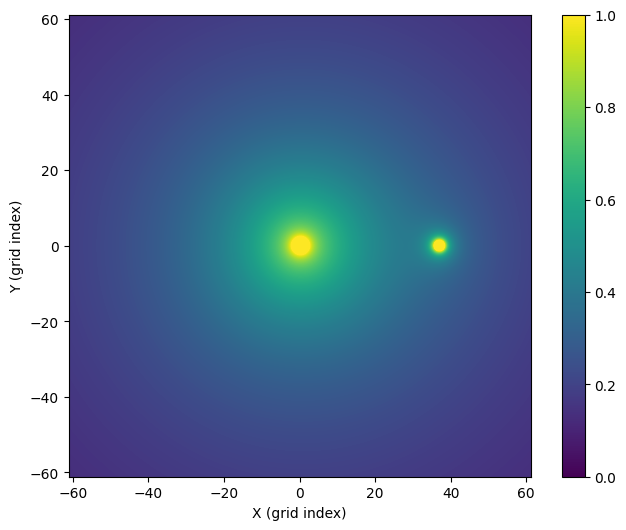

In [4]:
sidm_model_global.compute_kappa_map()
plot_map(sidm_model_global._kappa_map,xi1,xi2,vmax=1,vmin=0)

## Potential

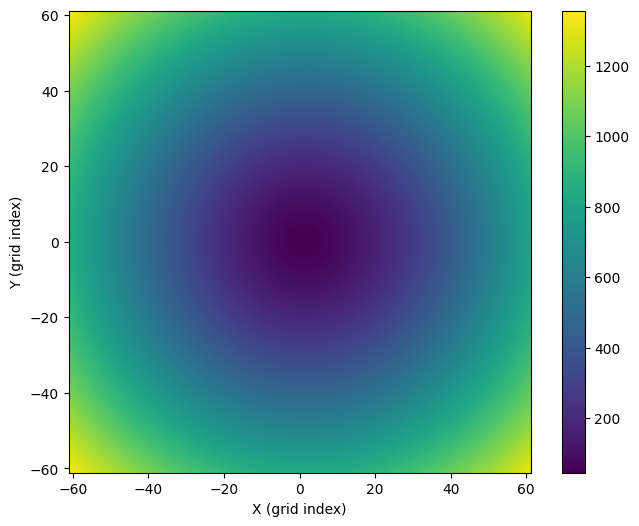

In [5]:
sidm_model_global.compute_potential_map()
plot_map(sidm_model_global._potential_map,xi1,xi2)

## alpha

In [6]:
alpha1_global, alpha2_global = sidm_model_global.compute_alpha_map()

plot_map(alpha1_global,xi1,xi2)
plot_map(alpha2_global,xi1,xi2)

TypeError: div got incompatible shapes for broadcasting: (1000000,), (2,).

## Critical and Caustic

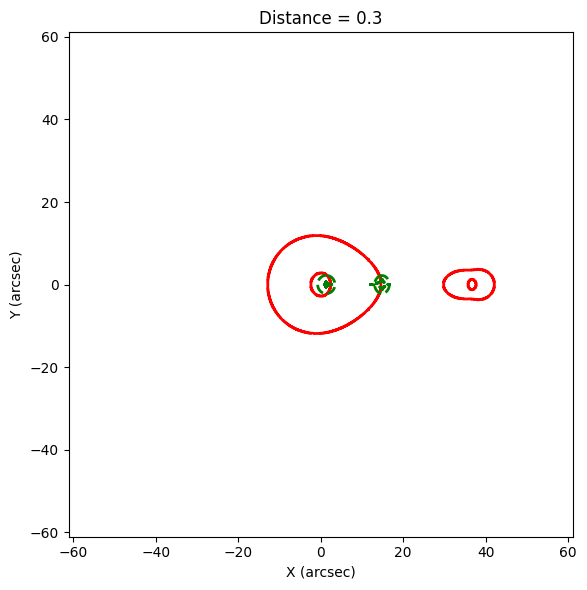

In [ ]:
yi1, yi2, mu_global, _,_,_ = alphas_to_mu(alpha1_global, alpha2_global, dsx_arc, xi1, xi2)
fig_combined, axes_combined = plt.subplots(1, 1, figsize=(8, 6))

ax = axes_combined
contour1 =ax.contour(xi2, xi1, mu_global, colors='red', linewidths=2, alpha=1)
contour2 =ax.contour(yi2, yi1, mu_global, colors='green', linewidths=2, alpha=1,linestyles='dashed')

ax.set_aspect('equal')
ax.set_title(f"Distance = {distance}")
ax.set_xlabel("X (arcsec)")
ax.set_ylabel("Y (arcsec)")

fig_combined.tight_layout()
plt.show()

# Using Fluid Simulation to Contrast

Input tr0: 0.001
Closest found tr: 0.001
Corresponding file: data_tr_0.001.pickle
Input tr0: 0.8
Closest found tr: 0.8007893386240001
Corresponding file: data_tr_0.8007893386240001.pickle


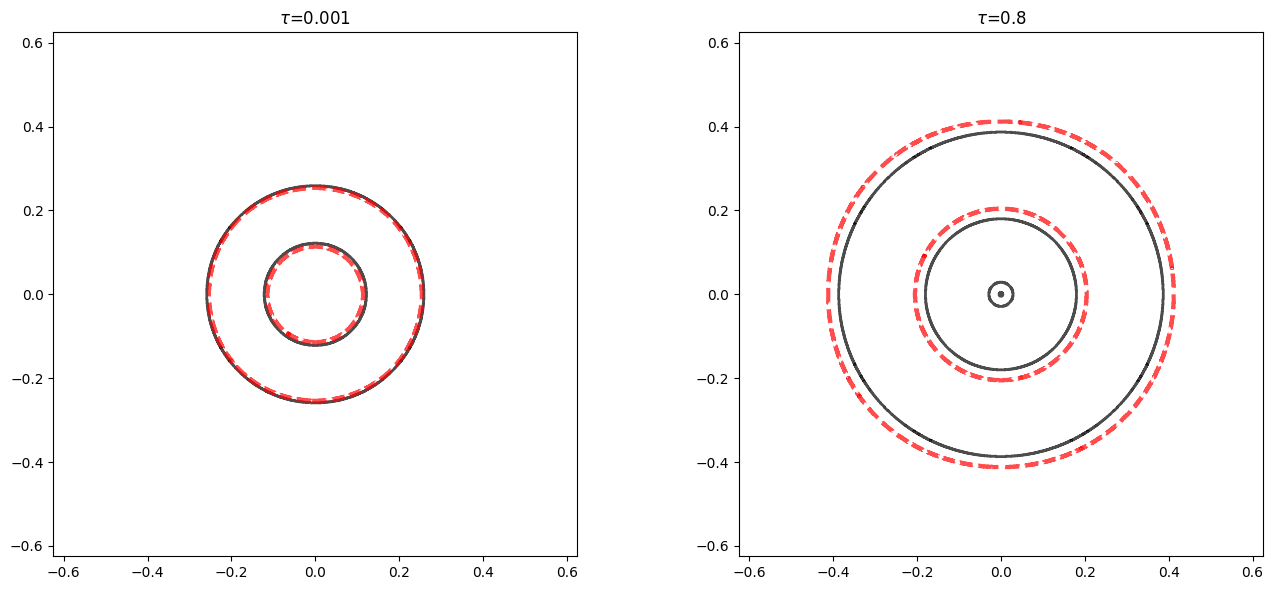

In [20]:
import matplotlib.pyplot as plt
from lenstronomy.Cosmo.nfw_param import NFWParam
from Lensing_tool import SigmaCrit, Da0, make_c_coor, alphas_to_mu,call_kappa_to_alphas
from astropy.cosmology import FlatwCDM
import numpy as np
from SIDM_density_fluid import refrence_Sigma
import pickle


# Initialize cosmology and parameters
cosmo = FlatwCDM(H0=70.0, Om0=0.3, Ob0=0.05, w0=-1.000000)
nfwpara = NFWParam(cosmo)

zlens = 0.439
zsource = 3
apr = 1.0 / np.pi * 180.0 * 3600  # arcsec per rad
Sigma_cr = SigmaCrit(zlens, zsource)
Mass_main = 5e15  # Msun
r200_main, rhos_main, Concentration_main, rs_main = nfwpara.nfw_Mz(Mass_main, zlens)
Da_zlens = Da0(zlens)
rs_arc_sidm = rs_main / Da_zlens * apr  # Convert to arcsec

taus = [0.001, 0.8]
# Prepare Figure 1: Global view
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))


for i, tau in enumerate(taus):
    halos = []
    # Main halo
    mainhalo = {
        'mass': Mass_main,
        'tnfw_params': {
            'rs': rs_main,
            'rhos': rhos_main
        },
        'redshift': zlens,
        'tau': tau,
        'position_x': 0,
        'position_y': 0
    }
    halos.append(mainhalo)

    # Global box size and grid setup
    bsz_arc = rs_arc_sidm * 2.5
    # bsz_arc = 20
    nnn = 4000
    dsx_arc = bsz_arc / nnn
    xi2, xi1 = make_c_coor(bsz_arc, nnn)
    filename = f"$\\tau$={tau}"
    # save_coordizxnates(filename, xi2, xi1, nnn)

    # SIDM model for global view
    sidm_model_global = SIDM_parametric(tnfw_params=halos, bsz_arc=bsz_arc, dsx_arc=dsx_arc, zsource=zsource)
    alpha1_global, alpha2_global = sidm_model_global.compute_alpha_map()
    y1_global, y2_global, mu_global,_,_,_ = alphas_to_mu(alpha1_global, alpha2_global, dsx_arc, xi1, xi2)

    Sigma_global_an,tr_real = refrence_Sigma(tau,xi2,xi1,rs_main,rhos_main,zlens)
    kappa_global_main = Sigma_global_an / Sigma_cr
    
    kappa_global = kappa_global_main 

    alpha1_global_fft, alpha2_global_fft = call_kappa_to_alphas(kappa_global, bsz_arc, nnn, boundary_type='I')
    y1_global_fft, y2_global_fft, mu_global_fft, kappa_fft,gamma1_fft,gamma2_fft = alphas_to_mu(alpha1_global_fft, alpha2_global_fft, dsx_arc, xi1, xi2)

    # Crop parameters
    crop_factor = 0.5 # Crop 50% of the image
    center = nnn // 2  # Center of the image
    crop_size = int(nnn * crop_factor / 2)  # Half of the crop size

    # 确定裁剪范围
    x_min, x_max = center - crop_size, center + crop_size
    y_min, y_max = center - crop_size, center + crop_size

    # 裁剪网格和数据
    xi1_crop = xi1[x_min:x_max, y_min:y_max]
    xi2_crop = xi2[x_min:x_max, y_min:y_max]
    mu_sub_crop = mu_global[x_min:x_max, y_min:y_max]
    mu_global_fft_crop = mu_global_fft[x_min:x_max, y_min:y_max]

    # Plot on the corresponding subplot
    ax = axes1[i]
    ax.contour(xi2_crop / rs_arc_sidm, xi1_crop / rs_arc_sidm, mu_sub_crop, colors='k', linewidths=2, alpha=0.7)
    ax.contour(xi2_crop / rs_arc_sidm, xi1_crop / rs_arc_sidm, mu_global_fft_crop, colors='r', linestyles='--', linewidths=3, alpha=0.7)
    ax.set_title(filename)
    ax.set_aspect('equal')

# Adjust layout and show
fig1.tight_layout()

plt.show()